In [1]:
from probjax.distributions import *
from probjax.distributions.transformed_distribution import TransformedDistribution
import jax
import jax.numpy as jnp

device = jax.devices("cpu")[0]
jax.default_device(device)


import matplotlib.pyplot as plt
key = jax.random.PRNGKey(0)

# Distributions

Just testing some of the distributions

## Continous Distributions

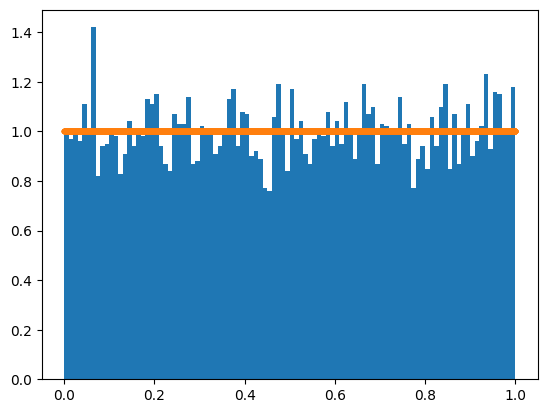

In [2]:
p = Uniform(low=0., high=1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


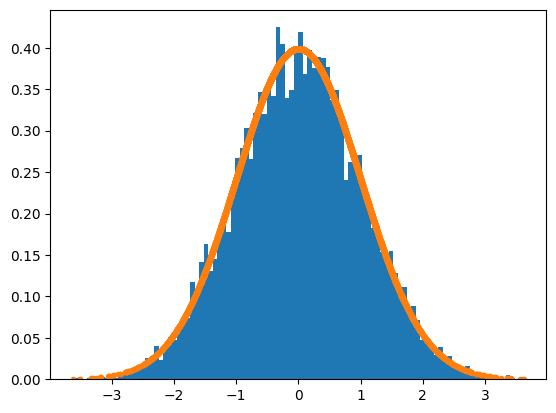

In [3]:
p = Normal(0.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


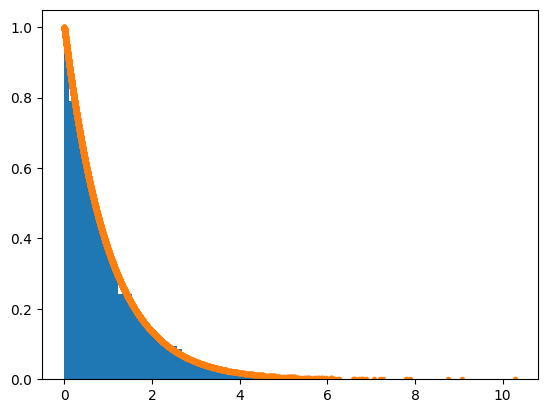

In [4]:
p = Gamma(1.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


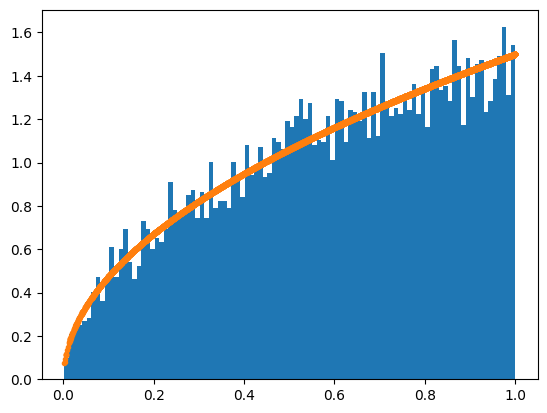

In [5]:
p = Beta(1.5,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


Array(True, dtype=bool)

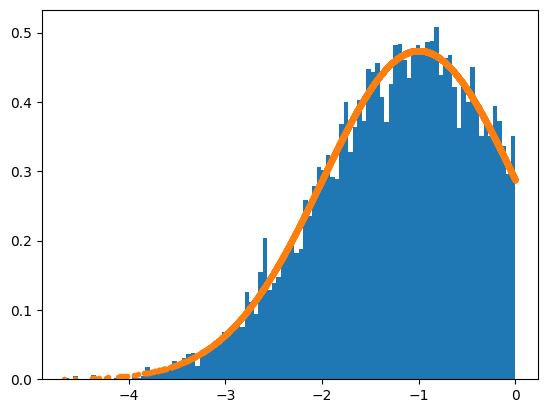

In [6]:
p = TruncatedNormal(-1.,1., low=-100., high=1.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
jnp.isfinite(log_prob).all()

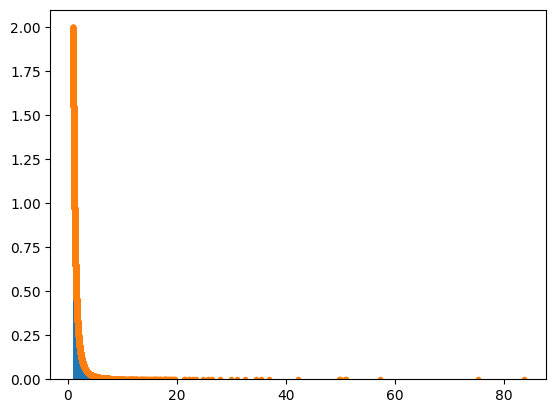

In [7]:
p = Pareto(2.,1.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

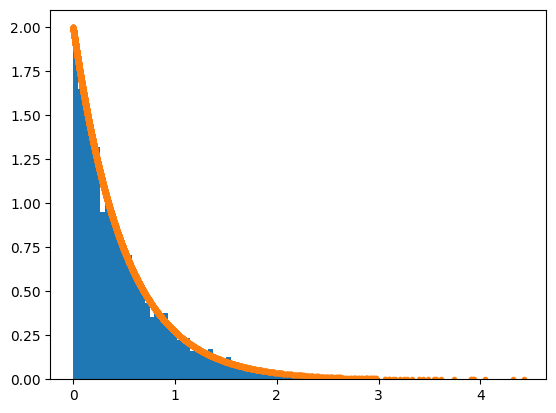

In [8]:
p = Exp(2.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

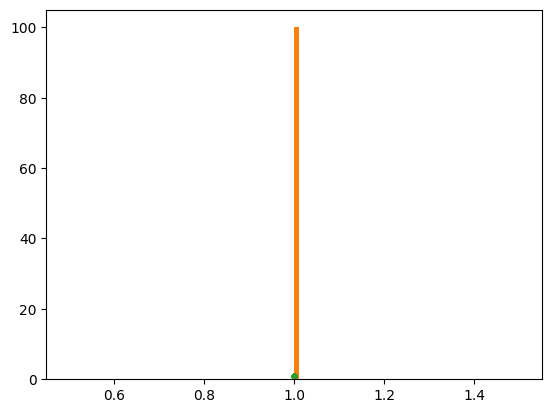

In [9]:
p = Dirichlet(jnp.array([1.]))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")



In [10]:
flatt_p, tree_p = jax.tree_util.tree_flatten(p)
q = jax.tree_util.tree_unflatten(tree_p, flatt_p)

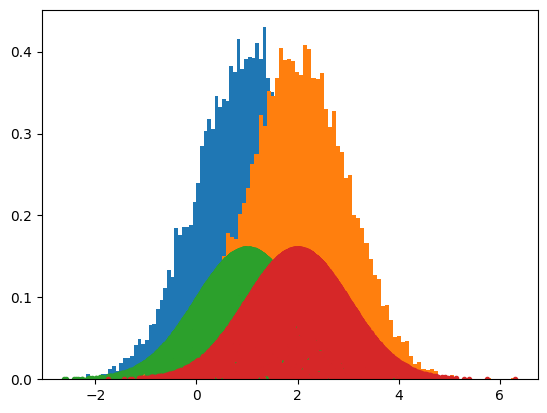

In [11]:
p = MultivariateNormal(jnp.array([1.,2.]), jnp.eye(2))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


## Discrete

(0.0, 1.0)

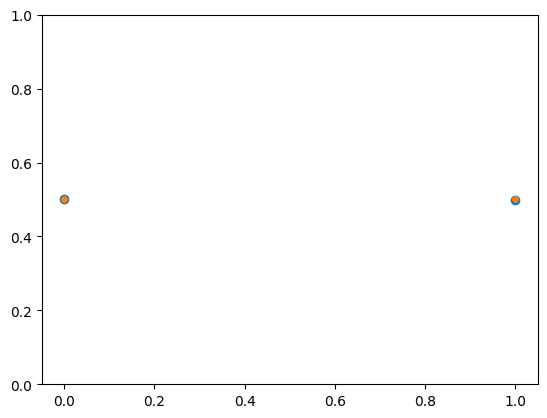

In [12]:
p = Bernoulli(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

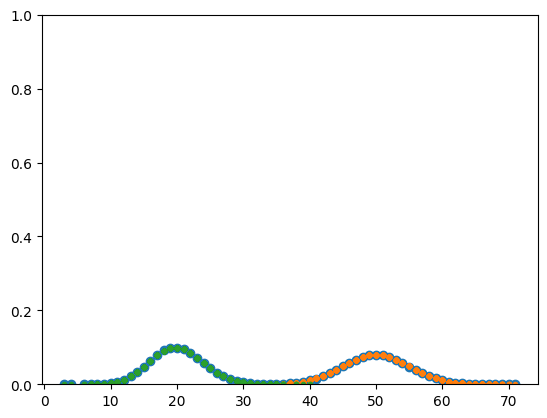

In [13]:
p = Binomial(jnp.array([100, 100]), jnp.array([0.5, 0.2]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

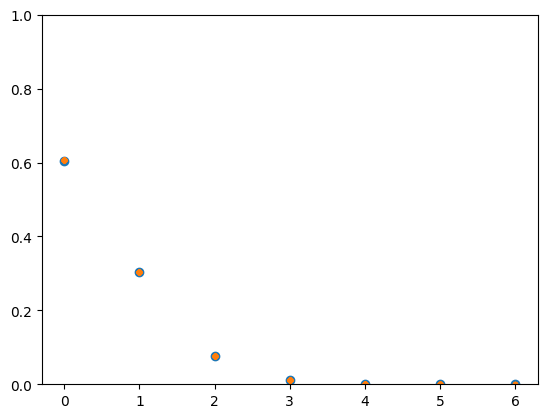

In [14]:
p = Poisson(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

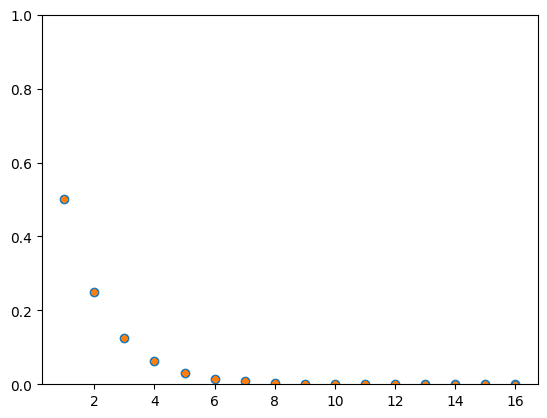

In [15]:
p = Geometric(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

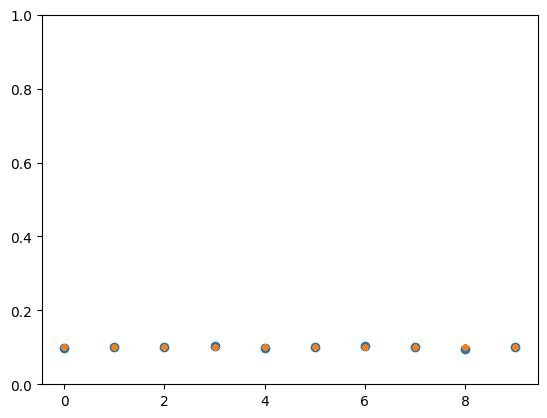

In [16]:
p = Categorical(jnp.ones((10)))
samples = p.sample(key, (10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

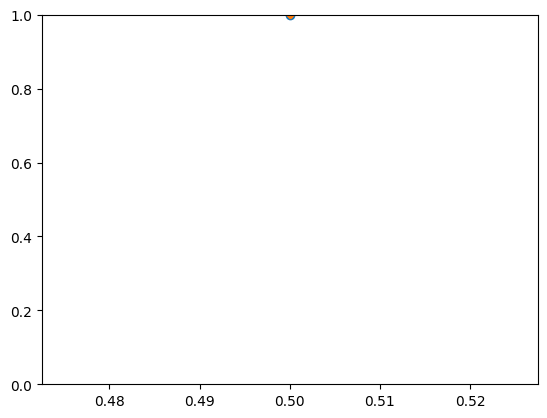

In [17]:
p = Dirac(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

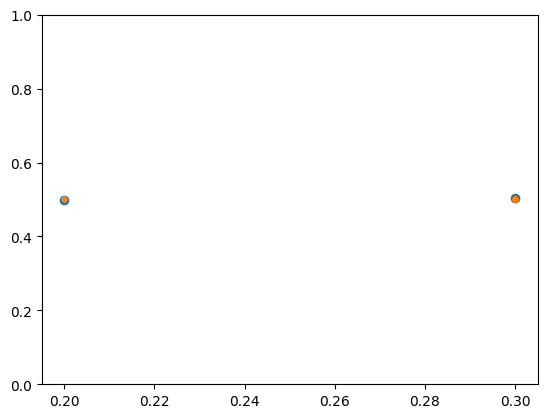

In [18]:
p = Empirical(jnp.array([0.2, 0.3]))
samples = p.sample(key, (10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".", color="C1")
plt.ylim(0,1)

# Independent

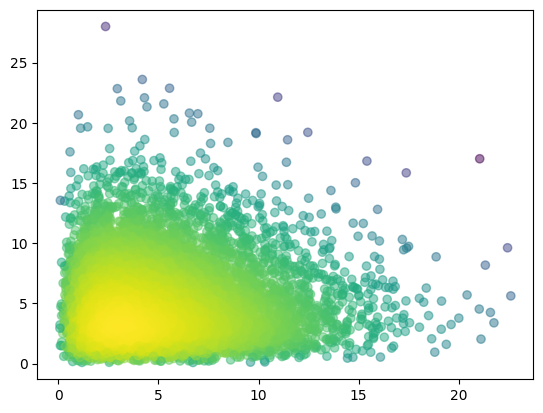

In [19]:
p1 = Chi2(5, jnp.zeros((2,)), jnp.ones((2,)))

p = Independent(p1, 1)

samples = p.sample(key, (10000,))
log_prob = p.log_prob(samples)

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

() (2,)
(10000,)


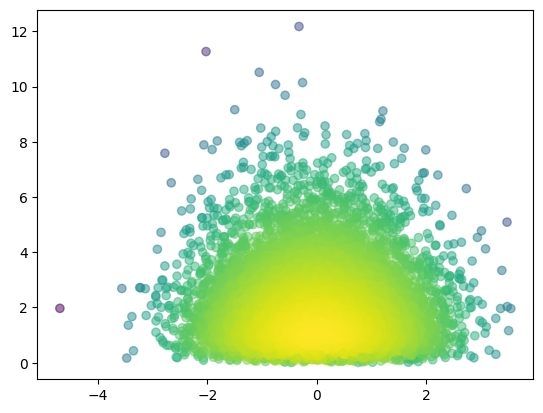

In [20]:
p1 = Normal(jnp.zeros((1,)), jnp.ones((1,)))
p2 = Gamma(jnp.ones((1,))*2, jnp.ones((1,)))

p = Independent([p1, p2], 1)
print(p1.event_shape, p.event_shape)

samples = p.sample(key, (10000,))
log_prob = p.log_prob(samples)

print(log_prob.shape)

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

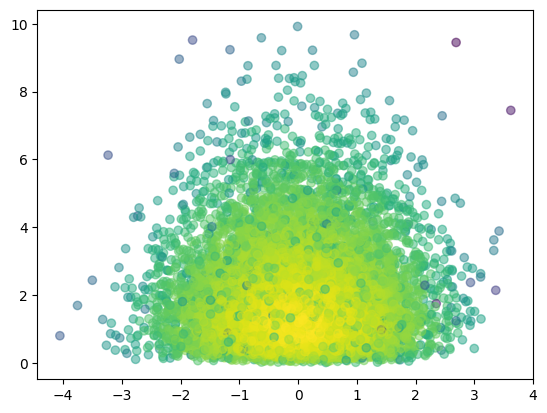

In [21]:
p1 = MultivariateNormal(jnp.zeros((2,)), jnp.eye(2))
p2 = Independent(Gamma(jnp.ones((1,))*2, jnp.ones((1,))),1)

p = Independent([p1, p2], 1)

samples = p.sample(key, (10000,))
log_prob = p.log_prob(samples)
plt.scatter(samples[:,0], samples[:,2], alpha=0.5, c=log_prob)

In [22]:
p.event_shape

(3,)

# Mixture

() (2,)
(10000, 2)
(10000,)


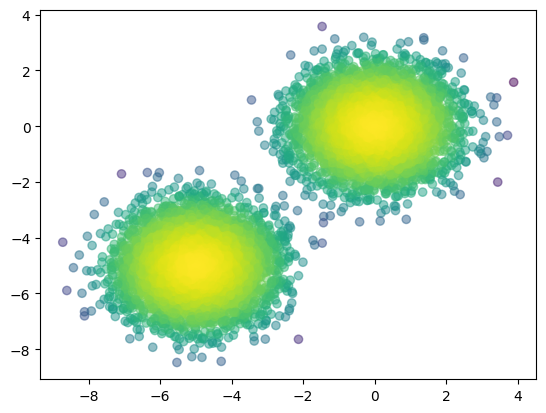

In [23]:
p1 = MultivariateNormal(jnp.array([0.,0.]),jnp.eye(2))
p2 = MultivariateNormal(jnp.array([-5., -5]),jnp.eye(2))
p = Mixture(jnp.array([0.5,0.5]), [p1,p2])
print(p.batch_shape, p.event_shape)
samples = p.sample(key, (10000,))
print(samples.shape)
#_ = plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
print(log_prob.shape) 
#plt.plot(samples, jnp.exp(log_prob), ".")

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c= log_prob)


() ()
(10000,)
(10000,)


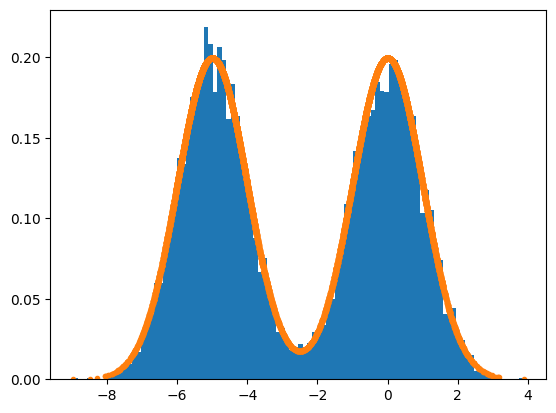

In [24]:
p1 = Normal(jnp.array([0.]),jnp.array([1.]))
p2 = Normal(jnp.array([-5.]),jnp.array([1.]))

p = Normal(jnp.array([0., -5.]),jnp.array([1., 1.]))

#p = Mixture(jnp.array([0.5,0.5]), p)
p = Mixture(jnp.array([0.5,0.5]), [p1,p2])
print(p.batch_shape, p.event_shape)
samples = p.sample(key, (10000,))
print(samples.shape)
_ = plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
print(log_prob.shape) 
plt.plot(samples, jnp.exp(log_prob), ".")

# SDEs

In [2]:
from probjax.distributions.sde import *

/tmp/ipykernel_80614/3160051518.py:1: DeprecationWarning: jax.random.PRNGKeyArray is deprecated. Use jax.Array for annotations, and jax.dtypes.issubdtype(arr, jax.dtypes.prng_key) for runtime detection of typed prng keys.
  from jax.random import PRNGKeyArray


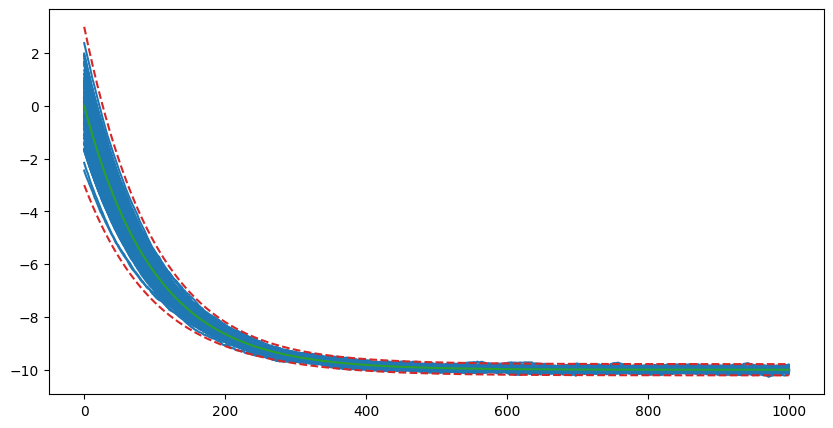

In [26]:
from jax.random import PRNGKeyArray
from jaxtyping import Array

key = jax.random.PRNGKey(0)
sde = OrnsteinUhlenbeck(1., -10., 0.1)
ts = jnp.linspace(0.0, 10.0, 1000)
x = sde.rsample(key, ts, (100,))
mean = sde.mean(ts)
std = sde.stddev(ts)

plt.figure(figsize=(10, 5))
_ = plt.plot(x.T, color="C0")
_ = plt.plot(mean, color="C2")
_ = plt.plot(mean + 3 * std, color="C3", linestyle="--")
_ = plt.plot(mean - 3 * std, color="C3", linestyle="--")


In [24]:
sde.diffusion(jnp.array([0.001]), jnp.array([0.00]))

Array([0.004], dtype=float32)

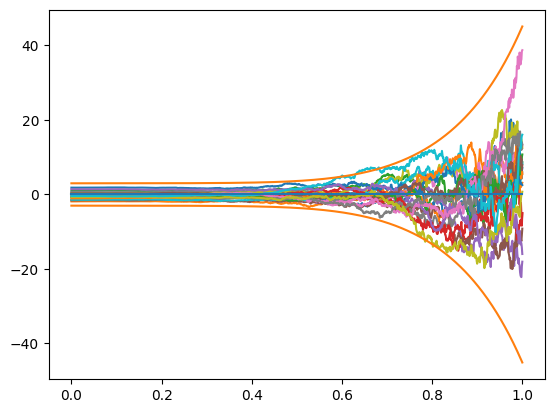

In [61]:
p0 = Normal(jnp.zeros(1), jnp.ones(1))
ts = jnp.linspace(0., 1., 1000)
sde = VESDE(p0, sigma_min=0.03, sigma_max=15.)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(20,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

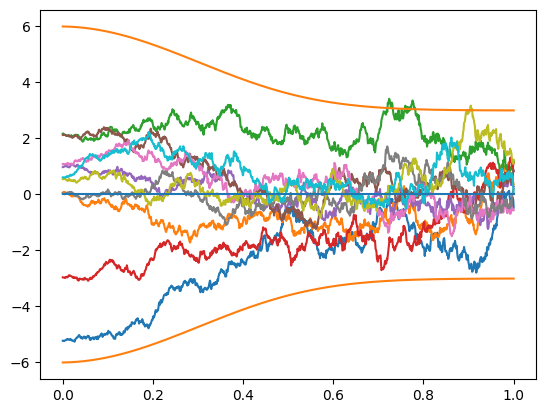

In [90]:
p0 = Normal(jnp.zeros(1), jnp.ones(1)*2)
ts = jnp.linspace(0., 1., 1000)
sde = VPSDE(p0, beta_min=0.1, beta_max=15.)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(10,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

In [87]:
def output_scale_fn(t, x):
    scale = jnp.sqrt(jnp.sum(sde.marginal_variance(t[..., None], x0=jnp.ones_like(x)), -1))
    return 1/scale[..., None] * x

In [89]:
float(sde.marginal_variance(jnp.array([1e-5]), x0=jnp.ones((1,))))

/tmp/ipykernel_24688/1139090748.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future.
  float(sde.marginal_variance(jnp.array([1e-5]), x0=jnp.ones((1,))))


1.0728836059570312e-06

In [55]:
def weight_fn(t):
    t = t.reshape(-1, 1)
    return jnp.clip(1-jnp.exp(-0.5 * (sde.beta_max - sde.beta_min) * t**2 - sde.beta_min * t) ,a_min = 1e-4)

In [66]:
float(weight_fn(jnp.array([1e-5])))

/tmp/ipykernel_24688/3403893814.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future.
  float(weight_fn(jnp.array([1e-5])))


9.999999747378752e-05

# Transformed Distributon

(0.0, 1.0)

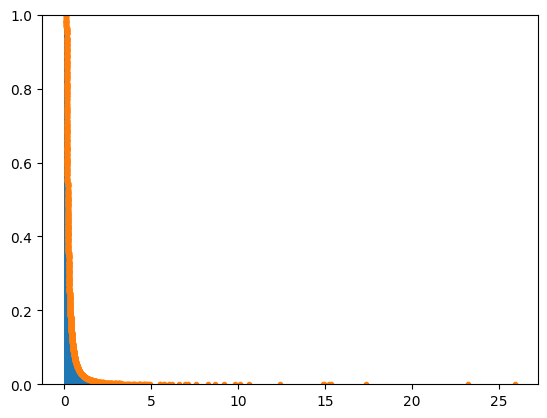

In [29]:
p0 = Normal(0.,1.)
p = TransformedDistribution(p0, lambda x: jnp.exp(x -2)**2)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

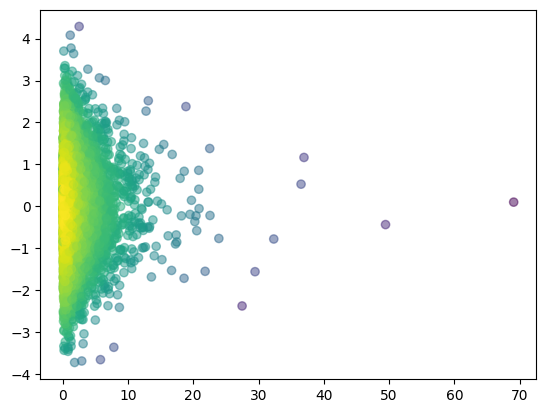

In [30]:
p0 = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)

def t(x):
    x = x.at[...,0].set(jnp.exp(x[...,0]))
    return x

p = TransformedDistribution(p0, t)
samples = p.sample(key, (10000,))

log_prob = p.log_prob(samples)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

## Divergences

### KL divergence

In [31]:
from probjax.distributions.divergences import kl_divergence

p0 = Normal(0.,1.)
p1 = Normal(0.,2.)
dist = kl_divergence(p0,p1)

dist

Array(0.318, dtype=float32, weak_type=True)

### Wassertsein

In [32]:
from probjax.distributions.divergences import wasserstein_distance

p0 = Normal(0.,1.)
p1 = Normal(0.,2.)

dist = wasserstein_distance(p0,p1)
dist

Array(1., dtype=float32, weak_type=True)